<h1 style="
    text-align:center;
    background-color:#004F98;
    color:white;
    padding:20px;
    border-radius:10px;">
    🔬🧬 Breast Cancer Diagnosis — Support Vector Classifier (SVC)
</h1>
<p style="text-align:center;color:#1F4E79;font-size:1rem;margin-top:10px;">
<b>Records:</b> 569 &nbsp;|&nbsp; <b>Features:</b> 30 &nbsp;|&nbsp; <b>Target:</b> Diagnosis (M / B) &nbsp;|&nbsp; <b>Malignant Rate:</b> 37.3%
</p>

<h2 style="color:#2E86C1;">
 1️⃣ 📚 Import Libraries
</h2>

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline         import Pipeline
from sklearn.svm              import SVC
from sklearn.metrics          import (confusion_matrix, accuracy_score,
                                       classification_report, roc_curve,
                                       auc, roc_auc_score,
                                       precision_recall_curve, ConfusionMatrixDisplay)
import pickle

<h2 style="color:#2E86C1;">
2️⃣ 🎯📖 Reading Dataset
</h2>

In [49]:
data = pd.read_csv('breast-cancer.csv')
df   = data.copy()
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<h2 style="color:#2E86C1;">
3️⃣ 𝄜 Data Shape
</h2>

In [50]:
print(f"  𝄜 Data Shape :{df.shape}")

  𝄜 Data Shape :(569, 32)


In [51]:
print(f'(☰)  Number of rows: {df.shape[0]}')
print(f'(|||) Number of columns: {df.shape[1]}')

(☰)  Number of rows: 569
(|||) Number of columns: 32


<h2 style="color:#2E86C1;">
4️⃣ 🔍 Initial Data Exploration
</h2>

In [52]:
print('📌 First 10 rows of the dataset:')
df.head(10)

📌 First 10 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [53]:
# Display last 5 rows
print('📌 Last 5 rows of the dataset:')
df.tail()

📌 Last 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [54]:
# General information about the dataset
print("\n" + "="*50 + "\n")
print('📋 Dataset Information:')
print(df.info())
print("\n" + "="*50 + "\n")



📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [8]:
# Column names
print("\n" + "="*100 + "\n")
print('📝 Column Names:')
print(df.columns.tolist())
print("\n" + "="*100 + "\n")



📝 Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']




In [9]:
# Descriptive statistics for numerical columns
print('📊 Descriptive Statistics (Numerical):')
df.describe().T

📊 Descriptive Statistics (Numerical):


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [56]:
# Descriptive statistics for categorical columns
print('📊 Descriptive Statistics (Categorical):')
df.describe(include='object').T

📊 Descriptive Statistics (Categorical):


,count,unique,top,freq
diagnosis,569,2,B,357


<h2 style="color:#2E86C1;">
5️⃣ 🧹 Data Cleaning & Preprocessing
</h2>

In [57]:
# ── Feature engineering ──────────────────────────────────────
df['DiagnosisLabel'] = df['diagnosis'].map({'M': 'Malignant', 'B': 'Benign'})
df['IsMalignant']    = df['diagnosis'].map({'M': 1, 'B': 0})

# ── Size category based on area_mean ─────────────────────────
df['TumorSize'] = pd.cut(
    df['area_mean'],
    bins=[0, 500, 1000, 2501],
    labels=['Small', 'Medium', 'Large']
)

# ── Compactness category ──────────────────────────────────────
df['CompactnessLevel'] = pd.cut(
    df['compactness_mean'],
    bins=[0, 0.08, 0.18, 0.40],
    labels=['Low', 'Moderate', 'High']
)

df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,DiagnosisLabel,IsMalignant,TumorSize,CompactnessLevel
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant,1,Large,High
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant,1,Large,Low
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant,1,Large,Moderate
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant,1,Small,High
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant,1,Large,Moderate


In [58]:
# Check for missing values
print('❌ Missing Values in Each Column:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "✅ No missing values found.")

❌ Missing Values in Each Column:
✅ No missing values found.


In [59]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f'🔍 Number of Duplicate Rows: {duplicates_count}')

🔍 Number of Duplicate Rows: 0


In [60]:
# Check for duplicate Columns
duplicates_count = df.T.duplicated().sum()
print(f'🔍 Number of Duplicate Columns: {duplicates_count}')

🔍 Number of Duplicate Columns: 0


In [61]:
print('='*60)
print('  DATASET OVERVIEW')
print('='*60)
print(f'  Total Records      : {df.shape[0]:,}')
print(f'  Total Features     : {df.shape[1]}')
print(f'  Malignant Cases    : {df["IsMalignant"].sum():,}  ({df["IsMalignant"].mean()*100:.1f}%)')
print(f'  Benign Cases       : {(df["IsMalignant"]==0).sum():,}  ({(df["IsMalignant"]==0).mean()*100:.1f}%)')
print(f'  Avg Radius (Mean)  : {df["radius_mean"].mean():.2f}')
print(f'  Avg Area (Mean)    : {df["area_mean"].mean():.2f}')
print(f'  Avg Concavity      : {df["concavity_mean"].mean():.4f}')
print(f'  Avg Compactness    : {df["compactness_mean"].mean():.4f}')
print('='*60)

  DATASET OVERVIEW
  Total Records      : 569
  Total Features     : 36
  Malignant Cases    : 212  (37.3%)
  Benign Cases       : 357  (62.7%)
  Avg Radius (Mean)  : 14.13
  Avg Area (Mean)    : 654.89
  Avg Concavity      : 0.0888
  Avg Compactness    : 0.1043


In [62]:
# Descriptive statistics for numerical columns
print('📊 Descriptive Statistics (Numerical):')
df.describe().T

📊 Descriptive Statistics (Numerical):


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


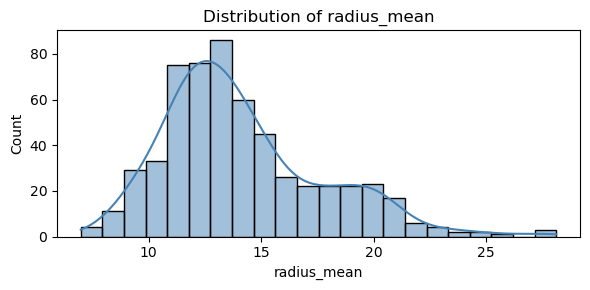

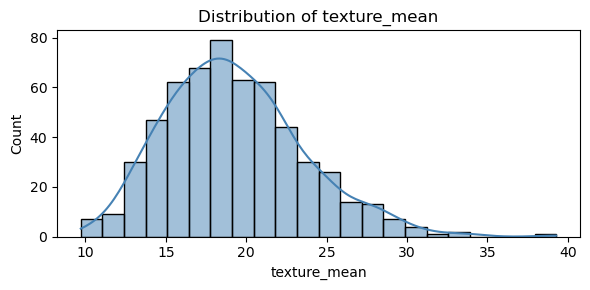

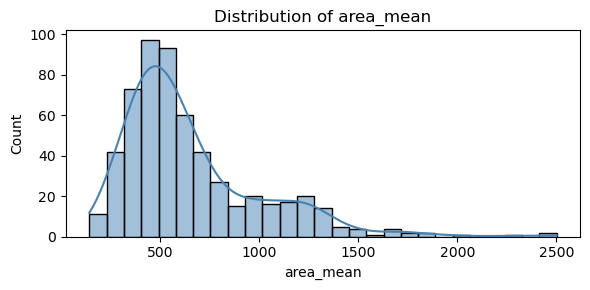

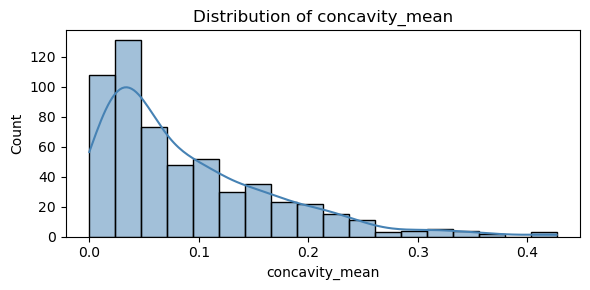

In [63]:
# Distribution of mean features
mean_cols = ['radius_mean', 'texture_mean', 'area_mean', 'concavity_mean']
for col in mean_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

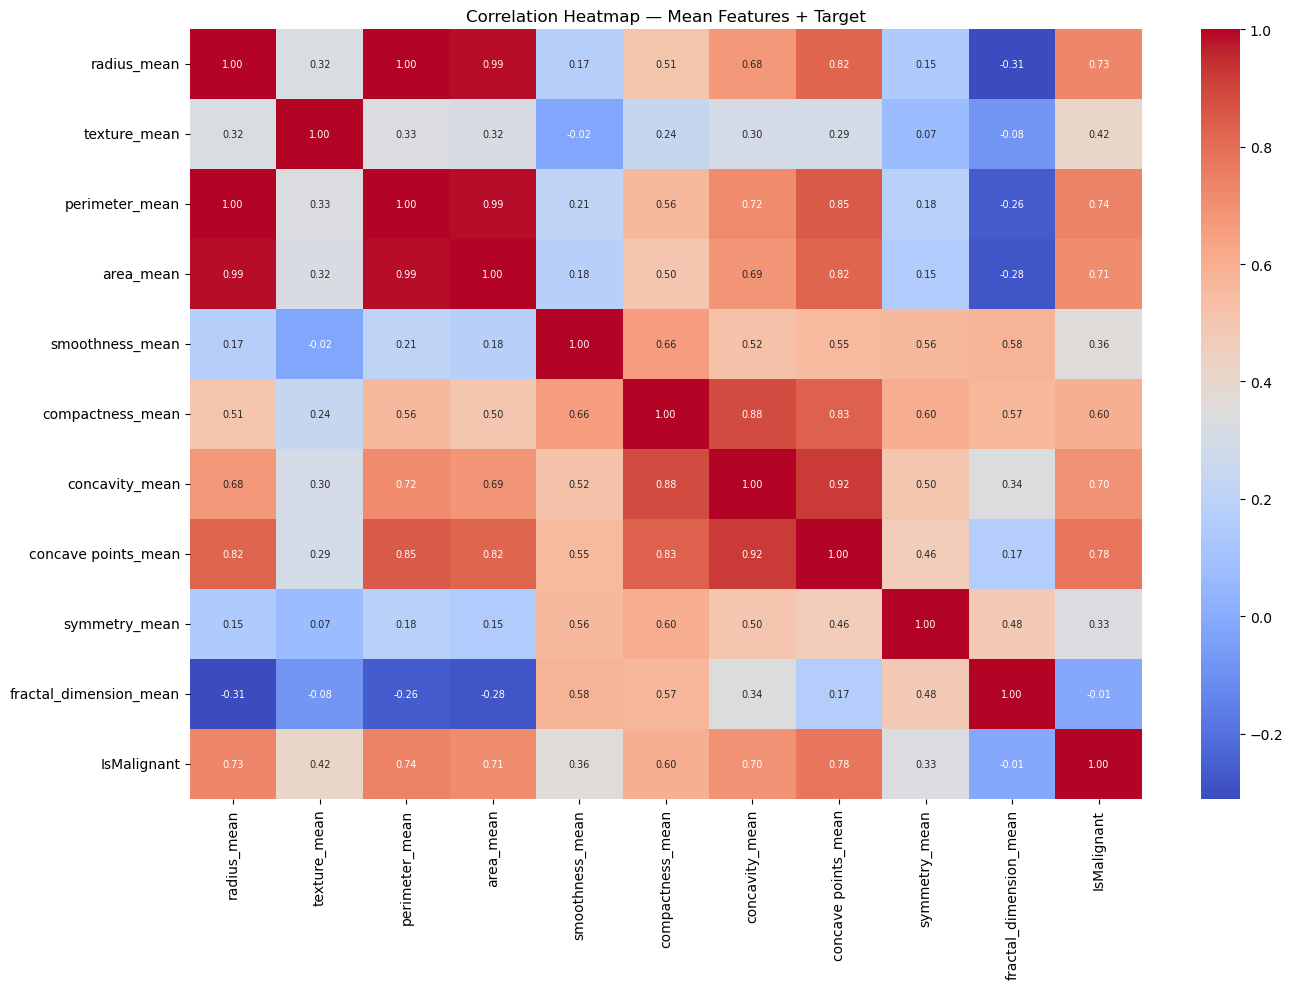

In [18]:
plt.figure(figsize=(14, 10))
mean_feat_cols = [c for c in df.columns if c.endswith('_mean')]
sns.heatmap(df[mean_feat_cols + ['IsMalignant']].corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            annot_kws={'size': 7})
plt.title('Correlation Heatmap — Mean Features + Target')
plt.tight_layout()
plt.show()

<h2 style="color:#2E86C1;">
6️⃣ 📈 Analysis Data
</h2>

📊  Diagnosis KPI :

In [64]:
Total_Cases      = df.shape[0]
Total_Malignant  = df['IsMalignant'].sum()
Total_Benign     = (df['IsMalignant'] == 0).sum()
Malignant_Rate   = (Total_Malignant / Total_Cases) * 100
Avg_Radius       = df['radius_mean'].mean()
Avg_Area         = df['area_mean'].mean()
Avg_Concavity    = df['concavity_mean'].mean()
Avg_Compactness  = df['compactness_mean'].mean()

print('='*60)
print('  DIAGNOSIS KPIs')
print('='*60)
print(f'  Total Cases         : {Total_Cases:,}')
print(f'  Malignant           : {Total_Malignant:,}  ({Malignant_Rate:.1f}%)')
print(f'  Benign              : {Total_Benign:,}  ({100-Malignant_Rate:.1f}%)')
print(f'  Avg Radius Mean     : {Avg_Radius:.2f}')
print(f'  Avg Area Mean       : {Avg_Area:.2f}')
print(f'  Avg Concavity Mean  : {Avg_Concavity:.4f}')
print(f'  Avg Compactness     : {Avg_Compactness:.4f}')
print('='*60)

  DIAGNOSIS KPIs
  Total Cases         : 569
  Malignant           : 212  (37.3%)
  Benign              : 357  (62.7%)
  Avg Radius Mean     : 14.13
  Avg Area Mean       : 654.89
  Avg Concavity Mean  : 0.0888
  Avg Compactness     : 0.1043


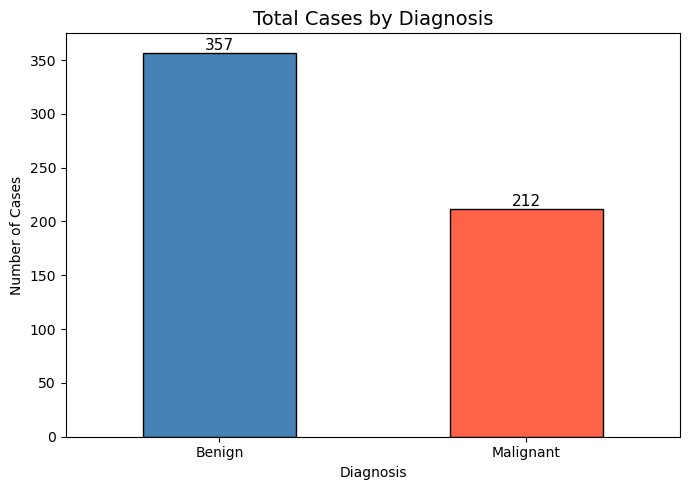

In [65]:
# Diagnosis count bar chart
diag_counts = df['DiagnosisLabel'].value_counts()
ax = diag_counts.plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    edgecolor='black',
    figsize=(7, 5)
)
plt.title('Total Cases by Diagnosis', fontsize=14)
plt.xlabel('Diagnosis')
plt.ylabel('Number of Cases')
for container in ax.containers:
    ax.bar_label(container, fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

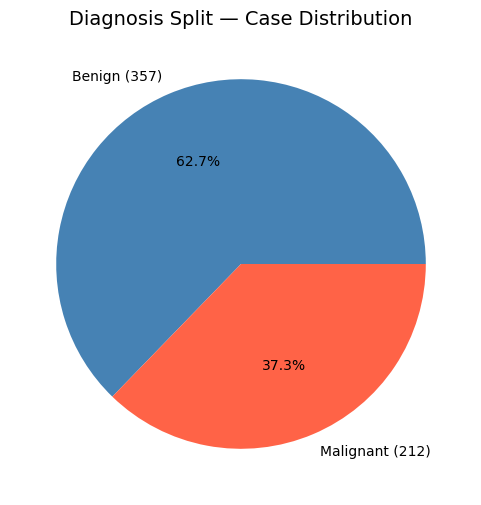

In [66]:
# Diagnosis pie chart
diag_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6),
    colors=['steelblue', 'tomato'],
    labels=[f'Benign ({diag_counts["Benign"]})',
            f'Malignant ({diag_counts["Malignant"]})']
)
plt.title('Diagnosis Split — Case Distribution', fontsize=14)
plt.ylabel('')
plt.show()

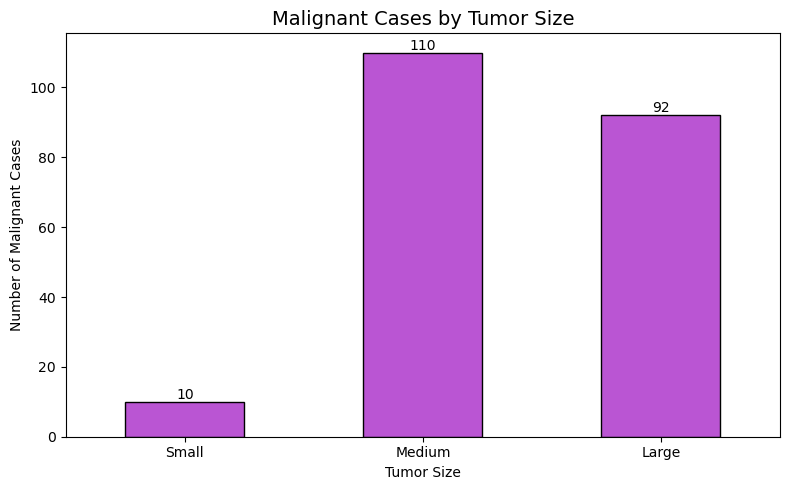

In [67]:
# Tumor size distribution by diagnosis
size_diag = df.groupby('TumorSize')['IsMalignant'].sum()
ax = size_diag.plot(
    kind='bar',
    color='mediumorchid',
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Malignant Cases by Tumor Size', fontsize=14)
plt.xlabel('Tumor Size')
plt.ylabel('Number of Malignant Cases')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

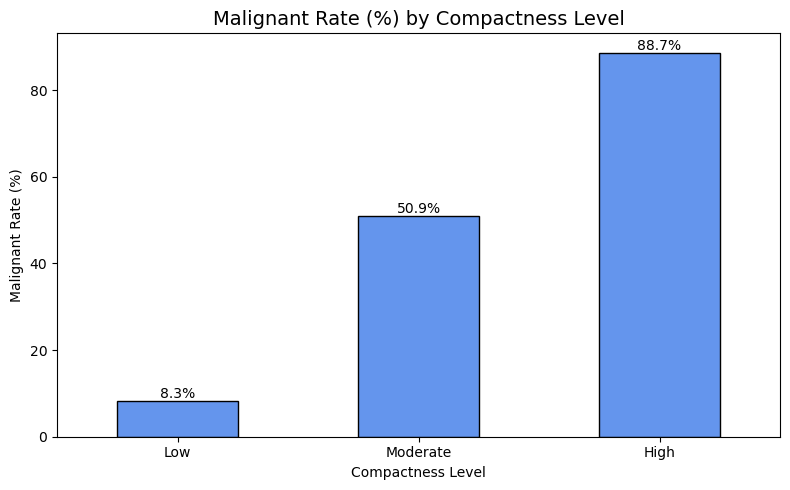

In [68]:
# Malignant rate by compactness level
compact_rate = df.groupby('CompactnessLevel')['IsMalignant'].mean() * 100
ax = compact_rate.plot(
    kind='bar',
    color='cornflowerblue',
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Malignant Rate (%) by Compactness Level', fontsize=14)
plt.xlabel('Compactness Level')
plt.ylabel('Malignant Rate (%)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

📊  Feature Group KPI :

In [69]:
feature_kpi = df.groupby('DiagnosisLabel').agg(
    Avg_Radius_Mean      = ('radius_mean',          'mean'),
    Avg_Texture_Mean     = ('texture_mean',          'mean'),
    Avg_Perimeter_Mean   = ('perimeter_mean',        'mean'),
    Avg_Area_Mean        = ('area_mean',             'mean'),
    Avg_Concavity_Mean   = ('concavity_mean',        'mean'),
    Avg_Compactness_Mean = ('compactness_mean',      'mean'),
    Avg_Radius_Worst     = ('radius_worst',          'mean'),
    Avg_Area_Worst       = ('area_worst',            'mean'),
).round(3)
feature_kpi

,Avg_Radius_Mean,Avg_Texture_Mean,Avg_Perimeter_Mean,Avg_Area_Mean,Avg_Concavity_Mean,Avg_Compactness_Mean,Avg_Radius_Worst,Avg_Area_Worst
DiagnosisLabel,,,,,,,,
Benign,12.147,17.915,78.075,462.790,0.046,0.080,13.380,558.899
Malignant,17.463,21.605,115.365,978.376,0.161,0.145,21.135,1422.286


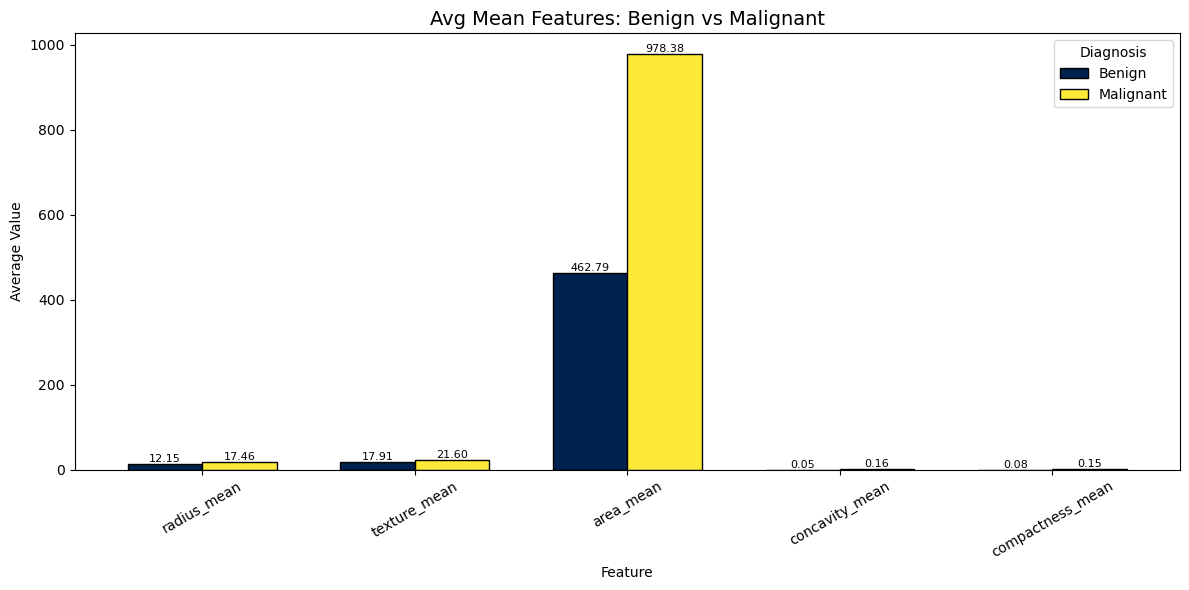

In [70]:
# Mean feature comparison — Malignant vs Benign
top_mean_feats = ['radius_mean', 'texture_mean', 'area_mean',
                  'concavity_mean', 'compactness_mean']
feat_compare = df.groupby('DiagnosisLabel')[top_mean_feats].mean()

ax = feat_compare.T.plot(
    kind='bar',
    figsize=(12, 6),
    edgecolor='black',
    width=0.7,
    colormap='cividis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8)
plt.title('Avg Mean Features: Benign vs Malignant', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=30)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

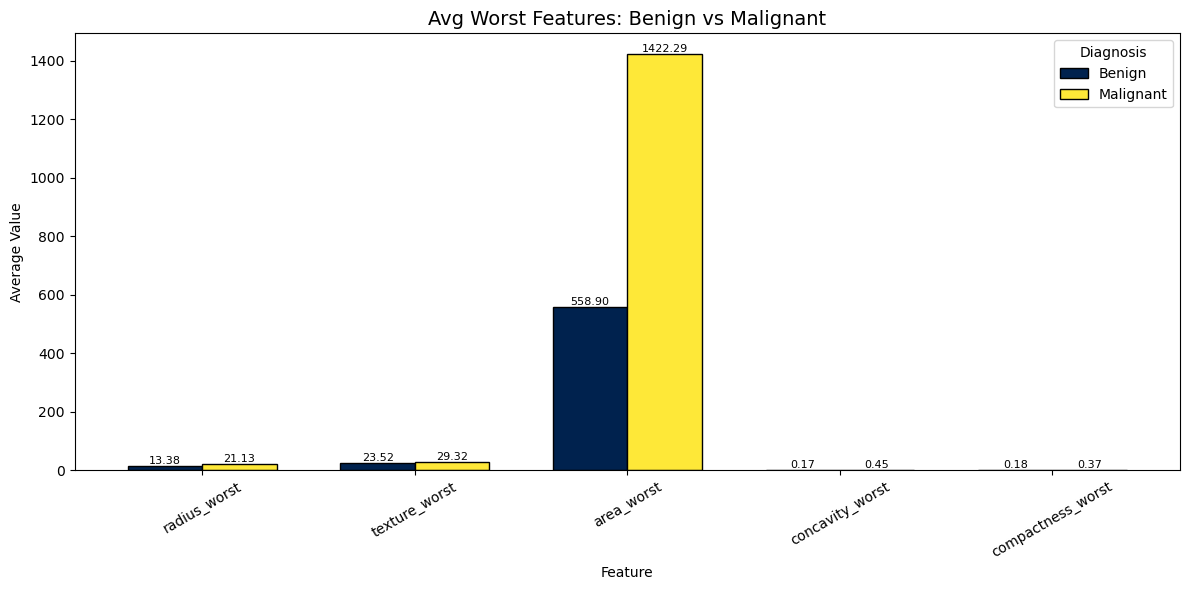

In [71]:
# Worst features comparison
worst_feats = ['radius_worst', 'texture_worst', 'area_worst',
               'concavity_worst', 'compactness_worst']
feat_worst = df.groupby('DiagnosisLabel')[worst_feats].mean()

ax = feat_worst.T.plot(
    kind='bar',
    figsize=(12, 6),
    edgecolor='black',
    width=0.7,
    colormap='cividis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8)
plt.title('Avg Worst Features: Benign vs Malignant', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=30)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

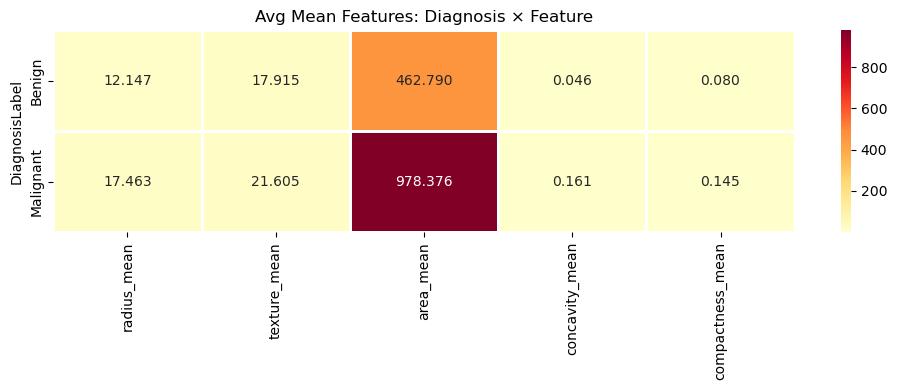

In [72]:
# Heatmap — Mean features by diagnosis
pivot_feat = df.groupby('DiagnosisLabel')[top_mean_feats].mean()

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_feat, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=2)
plt.title('Avg Mean Features: Diagnosis × Feature')
plt.tight_layout()
plt.show()

📊  Tumor Size & Morphology KPI :

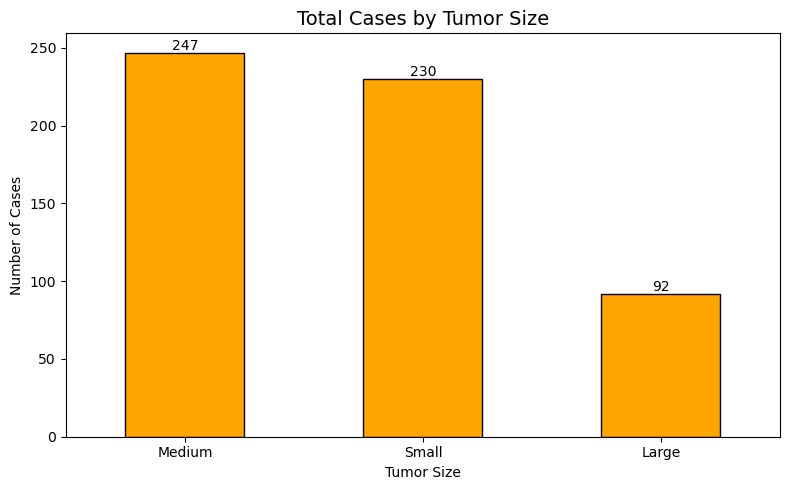

In [73]:
# Tumor size distribution overall
size_counts = df['TumorSize'].value_counts()
ax = size_counts.plot(
    kind='bar',
    color='orange',
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Total Cases by Tumor Size', fontsize=14)
plt.xlabel('Tumor Size')
plt.ylabel('Number of Cases')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

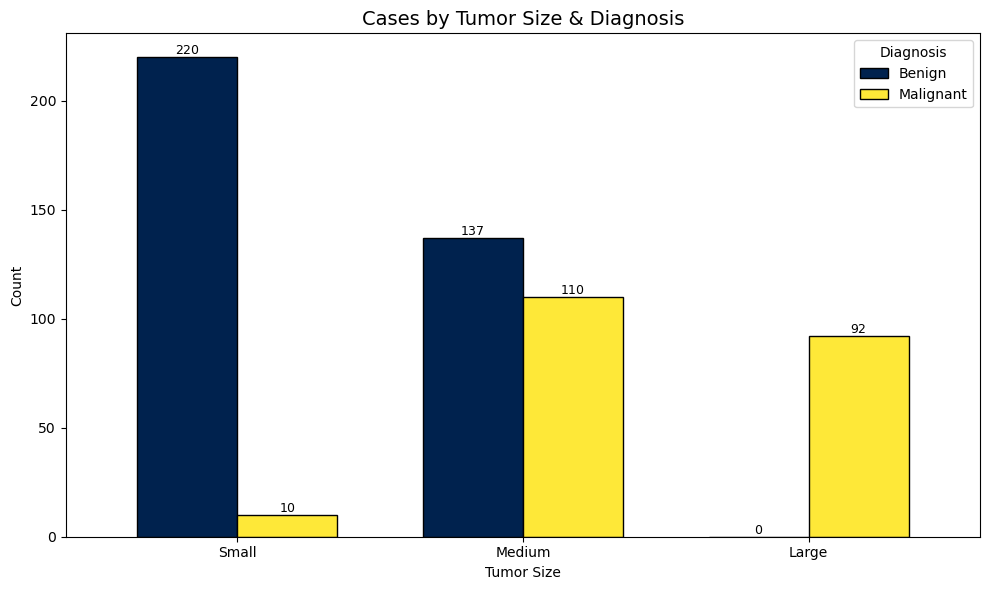

In [74]:
# Tumor size × diagnosis cross-tab
size_diag_cross = df.groupby(['TumorSize', 'DiagnosisLabel'])['IsMalignant'].count().reset_index()
pivot_size = size_diag_cross.pivot(index='TumorSize',columns='DiagnosisLabel',values='IsMalignant').fillna(0)
ax = pivot_size.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black',
    width=0.7,
    colormap='cividis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9)
plt.title('Cases by Tumor Size & Diagnosis', fontsize=14)
plt.xlabel('Tumor Size')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

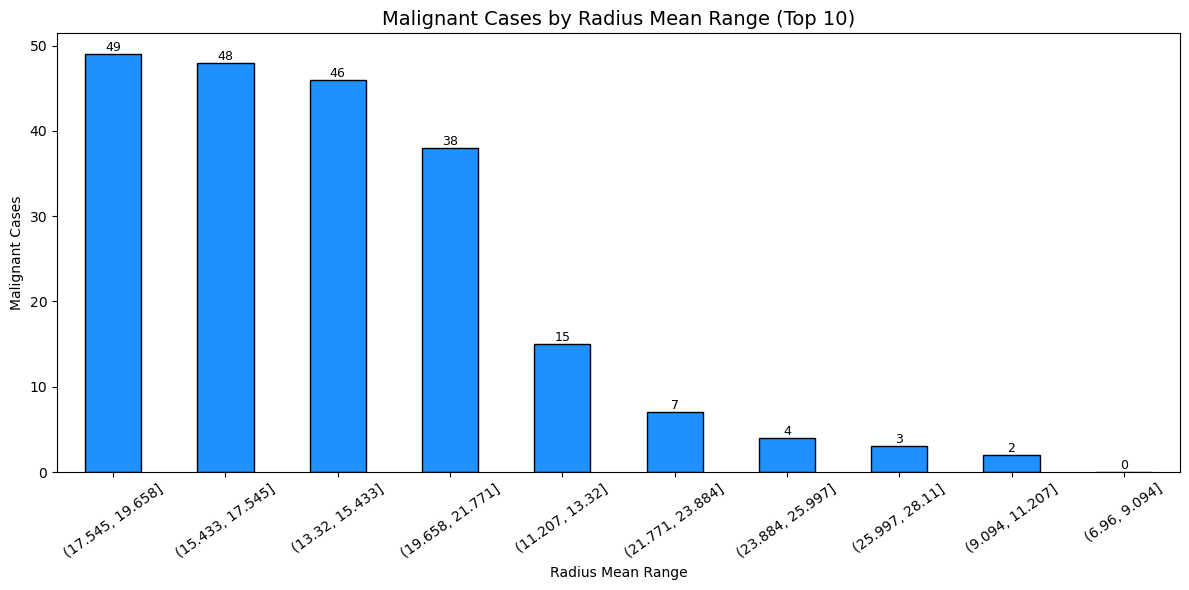

In [75]:
# Radius mean top 10 highest cases
radius_bins = df.copy()
radius_bins['radius_bin'] = pd.cut(df['radius_mean'], bins=10).astype(str)
radius_click = radius_bins.groupby('radius_bin')['IsMalignant'].sum().sort_values(ascending=False)

ax = radius_click.head(10).plot(
    kind='bar',
    color='dodgerblue',
    edgecolor='black',
    figsize=(12, 6)
)
plt.title('Malignant Cases by Radius Mean Range (Top 10)', fontsize=14)
plt.xlabel('Radius Mean Range')
plt.ylabel('Malignant Cases')
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

📊  Feature Behavior KPI :

In [76]:
feature_behavior_kpi = df.groupby('DiagnosisLabel').agg(
    Avg_Concave_Points = ('concave points_mean', 'mean'),
    Avg_Symmetry       = ('symmetry_mean',        'mean'),
    Avg_Fractal_Dim    = ('fractal_dimension_mean','mean'),
    Avg_Smoothness     = ('smoothness_mean',       'mean'),
).round(4)
feature_behavior_kpi

,Avg_Concave_Points,Avg_Symmetry,Avg_Fractal_Dim,Avg_Smoothness
DiagnosisLabel,,,,
Benign,0.0257,0.1742,0.0629,0.0925
Malignant,0.0880,0.1929,0.0627,0.1029


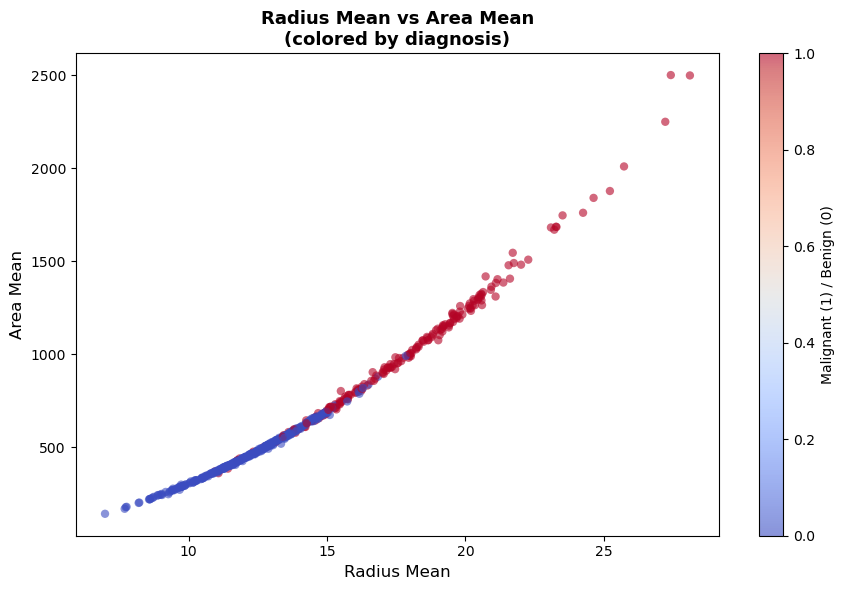

In [78]:
# Radius vs Area scatter (coloured by diagnosis)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['radius_mean'],
    df['area_mean'],
    c=df['IsMalignant'],
    cmap='coolwarm', alpha=0.6, edgecolors='none'
)
plt.colorbar(scatter, label='Malignant (1) / Benign (0)')
plt.xlabel('Radius Mean', fontsize=12)
plt.ylabel('Area Mean', fontsize=12)
plt.title('Radius Mean vs Area Mean\n(colored by diagnosis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

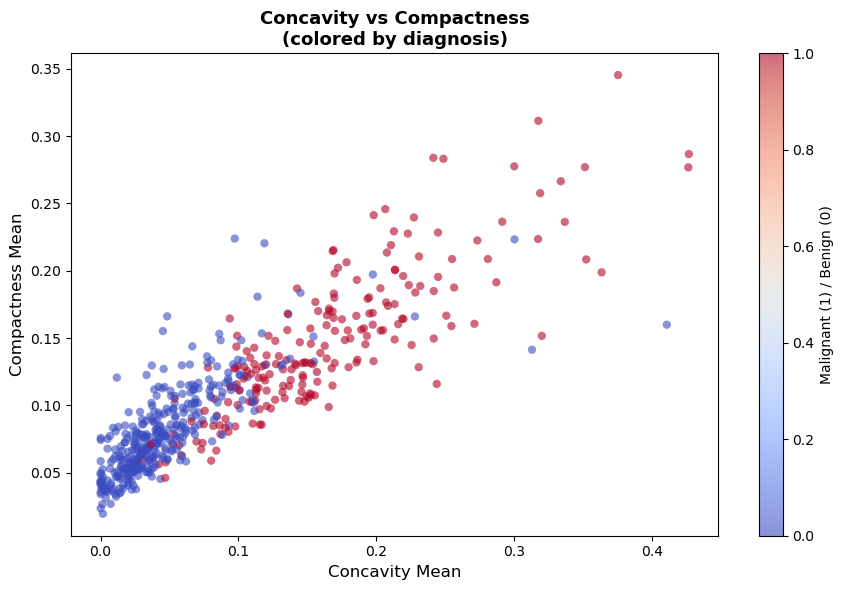

In [79]:
# Concavity vs Compactness scatter
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['concavity_mean'],
    df['compactness_mean'],
    c=df['IsMalignant'],
    cmap='coolwarm', alpha=0.6, edgecolors='none'
)
plt.colorbar(scatter, label='Malignant (1) / Benign (0)')
plt.xlabel('Concavity Mean', fontsize=12)
plt.ylabel('Compactness Mean', fontsize=12)
plt.title('Concavity vs Compactness\n(colored by diagnosis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [80]:
# ── KEY INSIGHTS & RECOMMENDATIONS ──────────────────────────
malignant_df = df[df['IsMalignant'] == 1]
benign_df    = df[df['IsMalignant'] == 0]

top_size       = df.groupby('TumorSize')['IsMalignant'].mean().idxmax()
top_compact    = df.groupby('CompactnessLevel')['IsMalignant'].mean().idxmax()
high_radius    = malignant_df['radius_mean'].mean()
high_area      = malignant_df['area_mean'].mean()
benign_radius  = benign_df['radius_mean'].mean()
malignant_rate = df['IsMalignant'].mean() * 100

insights = [
    ('🔴 Malignant Rate',       f'{malignant_rate:.1f}% of all cases are Malignant.'),
    ('📏 Radius Difference',    f'Malignant avg radius={high_radius:.2f} vs Benign avg radius={benign_radius:.2f}.'),
    ('📐 Area Insight',         f'Malignant tumours avg area ({high_area:.1f}) is significantly larger than Benign.'),
    ('🔷 Top Risk Size',        f'{top_size} tumours have the highest malignant rate.'),
    ('🔶 Compactness Risk',     f'{top_compact} compactness level correlates most with malignancy.'),
    ('📊 Concavity Signal',     'Concavity and concave points are strong predictors of malignancy.'),
    ('📉 Worst Features',       'The "worst" (largest) feature values outperform mean features as predictors.'),
]

print('='*65)
print('  KEY INSIGHTS & STRATEGIC TAKEAWAYS')
print('='*65)
for title, detail in insights:
    print(f'  {title}')
    print(f'     → {detail}')
    print()

print('CLINICAL RECOMMENDATIONS')
print('-'*65)
recs = [
    f'1. Patients with {top_size.lower()} tumours warrant immediate biopsy follow-up.',
    '2. radius_mean > 17 is a strong indicator of malignancy — flag for review.',
    f'3. {top_compact} compactness combined with high concavity = highest risk.',
    '4. Focus predictive models on "worst" feature group — highest signal quality.',
    '5. Concave points_worst and radius_worst are top 2 discriminating features.',
    '6. Regular screening reduces false negatives — model recall for M should be maximised.',
]
for r in recs:
    print(f'  {r}')
print('='*65)

  KEY INSIGHTS & STRATEGIC TAKEAWAYS
  🔴 Malignant Rate
     → 37.3% of all cases are Malignant.

  📏 Radius Difference
     → Malignant avg radius=17.46 vs Benign avg radius=12.15.

  📐 Area Insight
     → Malignant tumours avg area (978.4) is significantly larger than Benign.

  🔷 Top Risk Size
     → Large tumours have the highest malignant rate.

  🔶 Compactness Risk
     → High compactness level correlates most with malignancy.

  📊 Concavity Signal
     → Concavity and concave points are strong predictors of malignancy.

  📉 Worst Features
     → The "worst" (largest) feature values outperform mean features as predictors.

CLINICAL RECOMMENDATIONS
-----------------------------------------------------------------
  1. Patients with large tumours warrant immediate biopsy follow-up.
  2. radius_mean > 17 is a strong indicator of malignancy — flag for review.
  3. High compactness combined with high concavity = highest risk.
  4. Focus predictive models on "worst" feature group — hig

<h2 style="color:#2E86C1;">
6️⃣ 🔧 Define Features & Target
</h2>

In [81]:
# ── All 30 numerical features ────────────────────────────────
num_features = [
    'radius_mean','texture_mean','perimeter_mean','area_mean',
    'smoothness_mean','compactness_mean','concavity_mean',
    'concave points_mean','symmetry_mean','fractal_dimension_mean',
    'radius_se','texture_se','perimeter_se','area_se',
    'smoothness_se','compactness_se','concavity_se',
    'concave points_se','symmetry_se','fractal_dimension_se',
    'radius_worst','texture_worst','perimeter_worst','area_worst',
    'smoothness_worst','compactness_worst','concavity_worst',
    'concave points_worst','symmetry_worst','fractal_dimension_worst'
]

# ── Categorical features ──────────────────────────────────────
cat_features = []   # no categorical features in this dataset

# ── Target ───────────────────────────────────────────────────
TARGET = 'IsMalignant'

print('='*55)
print('  FEATURE SETUP')
print('='*55)
print(f'  Numerical   ({len(num_features)}) : {num_features[:5]} ...')
print(f'  Categorical ({len(cat_features)}) : {cat_features}')
print(f'  Target               : {TARGET}  (1=Malignant, 0=Benign)')
print('='*55)

  FEATURE SETUP
  Numerical   (30) : ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean'] ...
  Categorical (0) : []
  Target               : IsMalignant  (1=Malignant, 0=Benign)


In [82]:
X = df[num_features]
y = df[TARGET]

print(f'📌 X shape : {X.shape}')
print(f'📌 y shape : {y.shape}')
print(f'📌 Target distribution :\n{y.value_counts()}')

📌 X shape : (569, 30)
📌 y shape : (569,)
📌 Target distribution :
IsMalignant
0    357
1    212
Name: count, dtype: int64


# ✂️ Train-Test Split

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('='*45)
print('  TRAIN / TEST SPLIT')
print('='*45)
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Test     samples : {X_test.shape[0]}')
print(f'  Test size        : 20%')
print(f'  Stratified       : ✅ Yes')
print('='*45)

  TRAIN / TEST SPLIT
  Training samples : 455
  Test     samples : 114
  Test size        : 20%
  Stratified       : ✅ Yes


<h2 style="color:#2E86C1;">
7️⃣ ⚙️ Build the Pipeline
</h2>

In [92]:
# ── Step 1 : Preprocessor ────────────────────────────────────
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_features)
])


svc_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

# ── Step 2 : Full Pipeline ───────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   SVC(probability=True))
])

print('✅ Pipeline built successfully!')
print()
print(pipeline)

✅ Pipeline built successfully!

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['radius_mean',
                                                   'texture_mean',
                                                   'perimeter_mean',
                                                   'area_mean',
                                                   'smoothness_mean',
                                                   'compactness_mean',
                                                   'concavity_mean',
                                                   'concave points_mean',
                                                   'symmetry_mean',
                                                   'fractal_dimension_mean',
                  

<h2 style="color:#2E86C1;">
8️⃣ 🚀 Train the Pipeline
</h2>

In [93]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [94]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

In [95]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9868131868131869
Test Accuracy: 0.9736842105263158


<h2 style="color:#2E86C1;">
9️⃣ 📊 Model Evaluation
</h2>

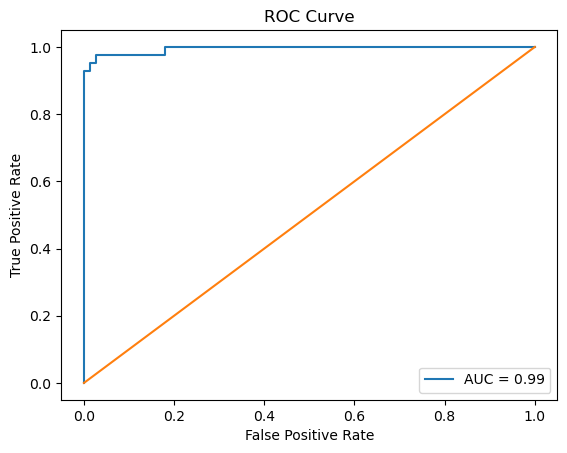

In [96]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.2f}")
plt.plot([0, 1], [0, 1])   # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [97]:
y_pred       = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print('='*50)
print('  MODEL PERFORMANCE')
print('='*50)
print(f'  🎯 Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  📈 ROC-AUC   : {roc_auc:.4f}')
print('='*50)
print()
print('📋 Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Benign (0)', 'Malignant (1)']))

  MODEL PERFORMANCE
  🎯 Accuracy  : 0.9737  (97.37%)
  📈 ROC-AUC   : 0.9947

📋 Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



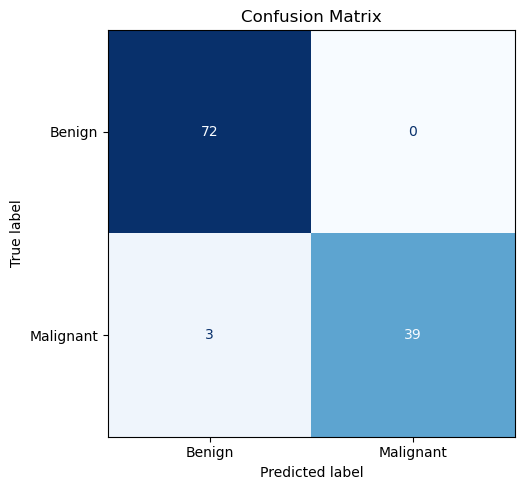

In [98]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 📌 13) Overfitting Check

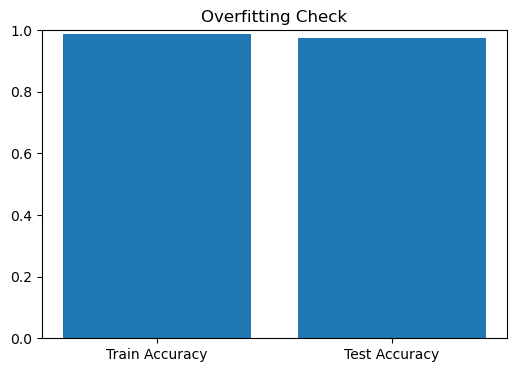

In [102]:
plt.figure(figsize=(6,4))
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc])
plt.title("Overfitting Check")
plt.ylim(0,1)
plt.show()

# 🧪 Test New Sample

In [103]:
def predict_sample(sample_dict):
    sample_df  = pd.DataFrame([sample_dict])
    prediction = pipeline.predict(sample_df)[0]
    proba      = pipeline.predict_proba(sample_df)[0]
    label      = 'Malignant ⚠️' if prediction == 1 else 'Benign  ✅'
    confidence = proba[prediction] * 100
    print(f'  Prediction  : {label}')
    print(f'  Confidence  : {confidence:.1f}%')
    print(f'  Benign Prob : {proba[0]*100:.1f}%   |   Malignant Prob : {proba[1]*100:.1f}%')
    return label

In [104]:
new_patient = {
    'radius_mean': 14.5,          'texture_mean': 20.1,
    'perimeter_mean': 95.0,       'area_mean': 680.0,
    'smoothness_mean': 0.10,      'compactness_mean': 0.12,
    'concavity_mean': 0.09,       'concave points_mean': 0.05,
    'symmetry_mean': 0.18,        'fractal_dimension_mean': 0.063,
    'radius_se': 0.42,            'texture_se': 1.20,
    'perimeter_se': 3.0,          'area_se': 42.0,
    'smoothness_se': 0.007,       'compactness_se': 0.025,
    'concavity_se': 0.030,        'concave points_se': 0.012,
    'symmetry_se': 0.020,         'fractal_dimension_se': 0.003,
    'radius_worst': 16.5,         'texture_worst': 26.0,
    'perimeter_worst': 109.0,     'area_worst': 900.0,
    'smoothness_worst': 0.135,    'compactness_worst': 0.26,
    'concavity_worst': 0.28,      'concave points_worst': 0.12,
    'symmetry_worst': 0.295,      'fractal_dimension_worst': 0.086,
}

predict_sample(new_patient)

  Prediction  : Benign  ✅
  Confidence  : 63.1%
  Benign Prob : 63.1%   |   Malignant Prob : 36.9%


'Benign  ✅'

# 💾 Save Model

In [106]:

with open('svc_breast_cancer.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print('✅ Model saved →svc_breast_cancer.pkl')

✅ Model saved →svc_breast_cancer.pkl
